# Global Supplier Disruption Risk Modeling: A Multivariate Analysis

## Methods

- Exgoneous Features analysis and correlation matrix
- PCA and discriminant analysis
- Temporal Features analysis
- Factor Analysis of Mixed Data
- Random Forest
- Network Graph Centrality Analysis
- Monte Carlo Scenario Simulation

In [1]:
import pandas as pd

file_path = r"C:\Users\leler\Documents\Personal project\Global Supply Chain Disruption & Resilience\archive\global_supply_chain_disruption_v1.csv"
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Column Names:")
print(df.columns.tolist())

df.head()

Dataset Shape: 10000 rows, 19 columns

Column Names:
['Order_ID', 'Order_Date', 'Origin_City', 'Destination_City', 'Route_Type', 'Transportation_Mode', 'Product_Category', 'Base_Lead_Time_Days', 'Scheduled_Lead_Time_Days', 'Actual_Lead_Time_Days', 'Delay_Days', 'Delivery_Status', 'Disruption_Event', 'Geopolitical_Risk_Index', 'Weather_Severity_Index', 'Inflation_Rate_Pct', 'Shipping_Cost_USD', 'Order_Weight_Kg', 'Mitigation_Action_Taken']


,Order_ID,Order_Date,Origin_City,Destination_City,Route_Type,Transportation_Mode,Product_Category,Base_Lead_Time_Days,Scheduled_Lead_Time_Days,Actual_Lead_Time_Days,Delay_Days,Delivery_Status,Disruption_Event,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg,Mitigation_Action_Taken
0,ORD-00BCB25B,2024-04-05,"Shanghai, CN","Los Angeles, US",Pacific,Sea,Textiles,18,21,18,0,On Time,NaN,0.81,8.9,1.83,1611.81,1781,Standard Shipping
1,ORD-EBDBACB7,2024-09-08,"Tokyo, JP","Singapore, SG",Intra-Asia,Air,Pharmaceuticals,2,5,2,0,On Time,NaN,0.70,5.9,2.44,76127.70,8142,Standard Shipping
2,ORD-4052DA06,2025-01-28,"Shenzhen, CN","Rotterdam, NL",Suez,Air,Semiconductors,3,4,4,0,On Time,NaN,0.46,8.1,3.86,13699.18,1706,Standard Shipping
3,ORD-03F41ABB,2025-02-04,"Santos, BR","Shanghai, CN",Commodity,Sea,Consumer Electronics,35,36,35,0,On Time,NaN,0.88,9.3,1.58,5448.24,5796,Standard Shipping
4,ORD-347A88A6,2025-05-20,"Hamburg, DE","New York, US",Atlantic,Sea,Raw Materials,12,13,12,0,On Time,NaN,0.55,2.9,3.12,1215.98,1569,Standard Shipping


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Define Continuous Exogenous Features for PCA
num_cols = [
    'Geopolitical_Risk_Index', 
    'Weather_Severity_Index', 
    'Inflation_Rate_Pct', 
    'Shipping_Cost_USD', 
    'Order_Weight_Kg'
]

# Define Categorical Features
cat_cols = [
    'Origin_City', 
    'Destination_City', 
    'Route_Type', 
    'Transportation_Mode', 
    'Product_Category', 
    'Disruption_Event'
]

# Standardize Matrix
scaler = StandardScaler()
X_num_std = scaler.fit_transform(df[num_cols])

print(f"PCA Input Matrix Shape: {X_num_std.shape}")
print(f"Categorical Variables Included: {len(cat_cols)} columns")

PCA Input Matrix Shape: (10000, 5)
Categorical Variables Included: 6 columns


## Correlation Analysis

Correlation Matrix


,Geopolitical_Risk_Index,Weather_Severity_Index,Inflation_Rate_Pct,Shipping_Cost_USD,Order_Weight_Kg
Geopolitical_Risk_Index,1.00,0.01,-0.00,0.09,-0.00
Weather_Severity_Index,0.01,1.00,-0.01,0.02,0.01
Inflation_Rate_Pct,-0.00,-0.01,1.00,-0.01,-0.01
Shipping_Cost_USD,0.09,0.02,-0.01,1.00,0.30
Order_Weight_Kg,-0.00,0.01,-0.01,0.30,1.00


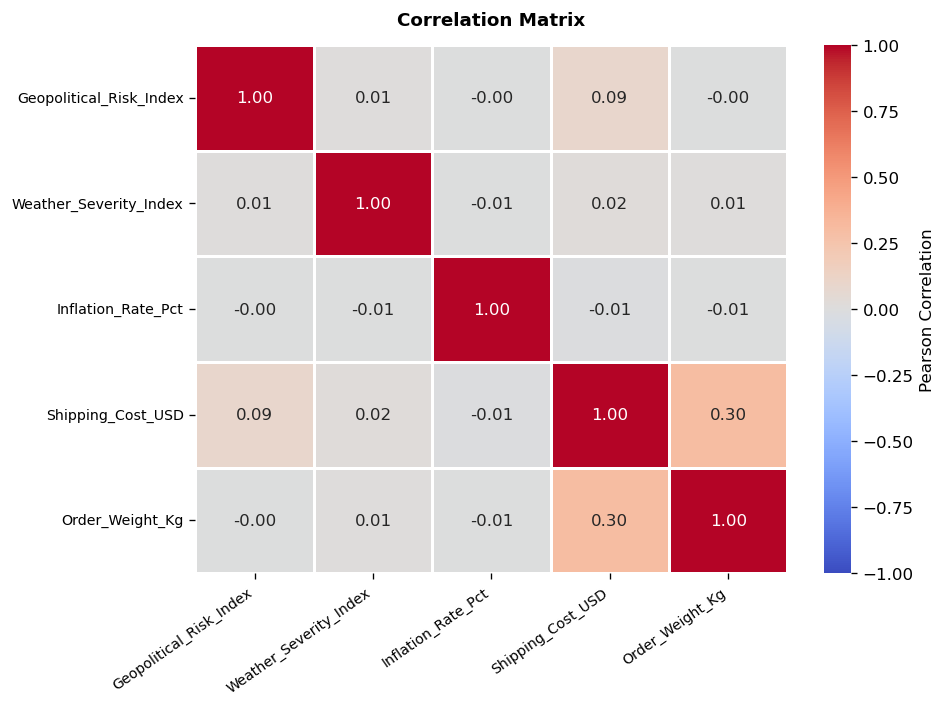

In [3]:
# Correlation Matrix
corr_matrix_pure = df[num_cols].corr()
print("Correlation Matrix")
display(corr_matrix_pure.round(2))

# Plot heatmap
plt.figure(figsize=(8, 6), dpi=120)
sns.heatmap(
    corr_matrix_pure, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1, 
    linewidths=0.8,
    cbar_kws={'label': 'Pearson Correlation'}
)

plt.title("Correlation Matrix", fontsize=11, fontweight="bold", pad=12)
plt.xticks(rotation=35, ha="right", fontsize=8.5)
plt.yticks(fontsize=8.5)
plt.tight_layout()
plt.show()

### Key Takeaway

- Heavier orders tend to cost more to ship (0.30), which aligns with standard freight pricing
- Bad weather, political risks, and inflation don't trigger or affect one another (0.00 to 0.02)
- No overlapping data so every metric brings its own unique value to the model

## PCA and Discriminant Analysis

In [4]:
# Covariance Matrix & Eigen-Decomposition
cov_matrix = np.cov(X_num_std, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort Eigen-pairs Descending
sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

# Variance Explained
var_explained = eigenvalues / np.sum(eigenvalues)
cum_var_explained = np.cumsum(var_explained)

print("PCA Variance Explained (Exogenous Factors Only)")
for i in range(len(var_explained)):
    print(f"PC{i+1} ({num_cols[sort_idx[i]]}): {var_explained[i]*100:.2f}% (Cumulative: {cum_var_explained[i]*100:.2f}%)")

PCA Variance Explained (Exogenous Factors Only)
PC1 (Geopolitical_Risk_Index): 26.37% (Cumulative: 26.37%)
PC2 (Inflation_Rate_Pct): 20.15% (Cumulative: 46.52%)
PC3 (Shipping_Cost_USD): 19.95% (Cumulative: 66.46%)
PC4 (Order_Weight_Kg): 19.87% (Cumulative: 86.33%)
PC5 (Weather_Severity_Index): 13.67% (Cumulative: 100.00%)


### Key Takeaways:

- Geopolitical risk is the single largest factor since it account for the biggest share (26.4%) of variation across your dataset
- Political unstability, inflation, and shipping costs capture 66.5% of teh variance
- Weather has the smallest impact since weather severity accounts for the lowest individual share (13.7%) of overall variation

In [5]:
# Categorical Variables
X_cat_encoded = pd.get_dummies(df[cat_cols], drop_first=True)

# Combine Exogenous Continuous and Categoricals variables
X_full = pd.concat([df[num_cols], X_cat_encoded], axis=1)
y_delay = df['Delay_Days']

# Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_full, y_delay)

# Top 10 Drivers
importances = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance_Pct': rf_model.feature_importances_ * 100
}).sort_values(by='Importance_Pct', ascending=False)

print("Top 10 Drivers of Delivery Delays")
display(importances.head(10).style.format({'Importance_Pct': '{:.2f}%'}))

Top 10 Drivers of Delivery Delays


,Feature,Importance_Pct
3,Shipping_Cost_USD,38.70%
4,Order_Weight_Kg,19.04%
0,Geopolitical_Risk_Index,10.08%
19,Transportation_Mode_Sea,9.96%
18,Route_Type_Suez,6.55%
27,Disruption_Event_Severe Weather (Typhoon/Storm),4.66%
26,Disruption_Event_Port Congestion,4.57%
2,Inflation_Rate_Pct,2.53%
1,Weather_Severity_Index,2.28%
23,Product_Category_Raw Materials,0.21%


### Key Takeaway

- Shipment size (19.0%) and cost (38.7%) drive most delays. Together they account for nearly 58% of all delays.
- Geopolitical instability (10.1%) has a bigger impact on schedules than severe weather (4.7%).
- Shipping by sea (10.0%) and taking key maritime routes like the Suez Canal (6.6%) caused the most slowdowns between the various transportation mode.

## Vizualization

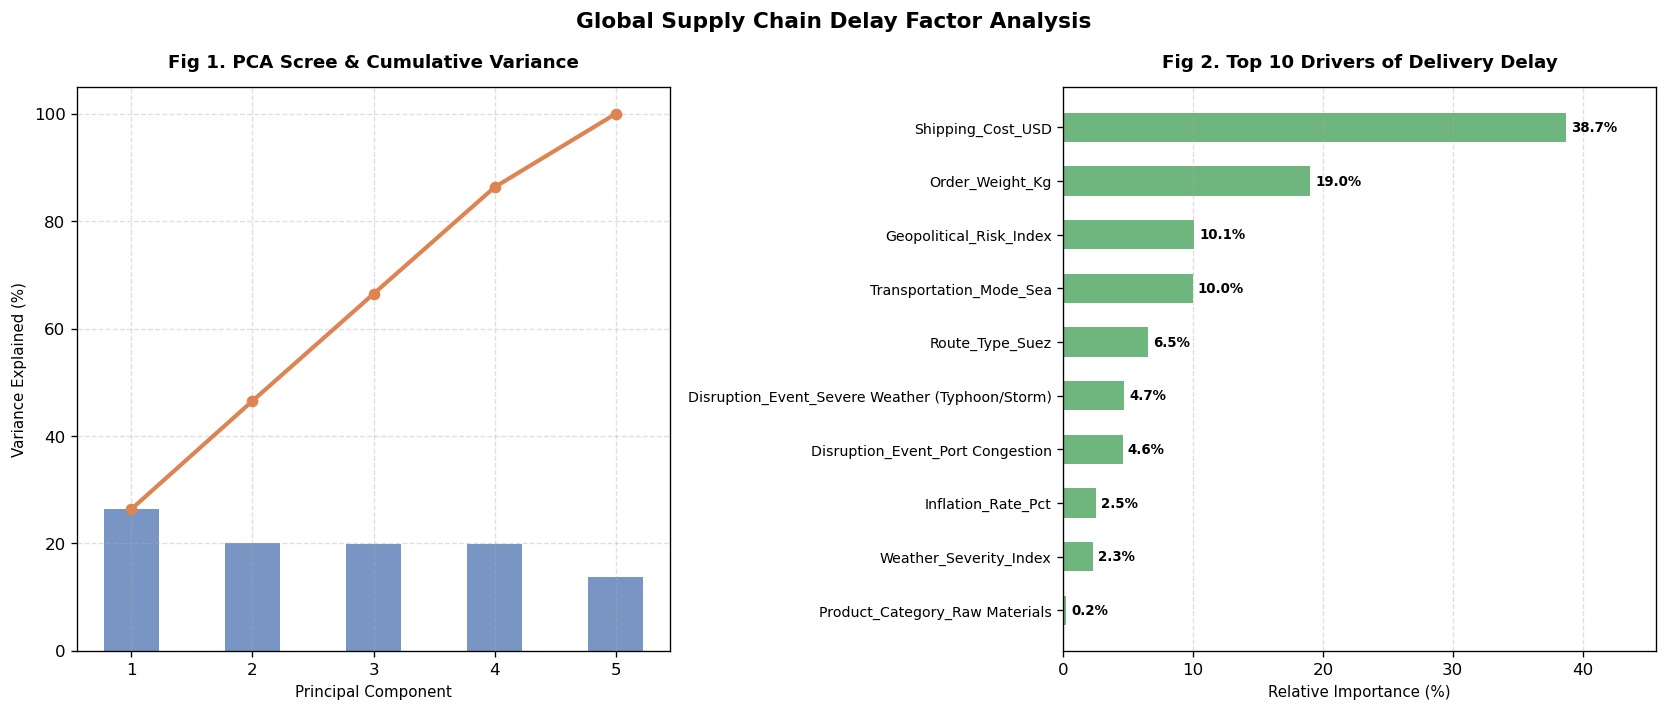

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)
plt.subplots_adjust(wspace=0.38)

# Figure 1: PCA & Cumulative Variance
axes[0].bar(range(1, len(var_explained)+1), var_explained*100, alpha=0.75, color='#4c72b0', width=0.45)
axes[0].plot(range(1, len(var_explained)+1), cum_var_explained*100, marker='o', color='#dd8452', linewidth=2.5, markersize=6)
axes[0].set_title('Fig 1. PCA Scree & Cumulative Variance', fontsize=11, fontweight='bold', pad=12)
axes[0].set_xlabel('Principal Component', fontsize=9)
axes[0].set_ylabel('Variance Explained (%)', fontsize=9)
axes[0].set_xticks(range(1, len(var_explained)+1))
axes[0].set_ylim(0, 105)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Figure 2: Top 10 Delay Drivers
top10 = importances.head(10).iloc[::-1]
bars = axes[1].barh(top10['Feature'], top10['Importance_Pct'], color='#55a868', alpha=0.85, height=0.55)

for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 0.4, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                 va='center', ha='left', fontsize=8, fontweight='bold')

axes[1].set_title('Fig 2. Top 10 Drivers of Delivery Delay', fontsize=11, fontweight='bold', pad=12)
axes[1].set_xlabel('Relative Importance (%)', fontsize=9)
axes[1].set_xlim(0, max(top10['Importance_Pct']) * 1.18)
axes[1].grid(True, linestyle='--', alpha=0.4, axis='x')
axes[1].tick_params(axis='y', labelsize=8.5)

plt.suptitle('Global Supply Chain Delay Factor Analysis', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Investigating Temporal Features

In [7]:
# Temporal features
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Month'] = df['Order_Date'].dt.month_name()

# Delay rate by Transportation Mode and Route Type
mode_route_delay = df.groupby(['Transportation_Mode', 'Route_Type'])['Delay_Days'].agg(['count', 'mean', 'median']).reset_index()
print("Average Delay Days by Mode and Route ")
display(mode_route_delay.sort_values(by='mean', ascending=False))

# Top 5 Worst Origin-Destination City Corridors for Delays
city_lane_delay = df.groupby(['Origin_City', 'Destination_City'])['Delay_Days'].agg(['count', 'mean']).reset_index()
city_lane_delay = city_lane_delay[city_lane_delay['count'] > 10]  # Filter for recurring routes

print("Top 5 Delay-Prone City Corridors")
display(city_lane_delay.sort_values(by='mean', ascending=False).head(5))

Average Delay Days by Mode and Route 


,Transportation_Mode,Route_Type,count,mean,median
4,Air,Suez,595,2.013445,0.0
9,Sea,Suez,2817,1.976216,0.0
7,Sea,Intra-Asia,1353,0.575758,0.0
8,Sea,Pacific,1392,0.467672,0.0
3,Air,Pacific,253,0.462451,0.0
2,Air,Intra-Asia,281,0.370107,0.0
5,Sea,Atlantic,1390,0.356835,0.0
6,Sea,Commodity,1319,0.299469,0.0
0,Air,Atlantic,311,0.299035,0.0
1,Air,Commodity,289,0.259516,0.0


Top 5 Delay-Prone City Corridors


,Origin_City,Destination_City,count,mean
1,"Mumbai, IN","Felixstowe, UK",1710,2.146784
4,"Shenzhen, CN","Rotterdam, NL",1702,1.817861
5,"Tokyo, JP","Singapore, SG",1634,0.540392
3,"Shanghai, CN","Los Angeles, US",1645,0.466869
0,"Hamburg, DE","New York, US",1701,0.346267


### Key Takeaways

- Disruptions are route-specific: the typical shipment across all routes arrives on time with 0 days of delay, however the mean is greater than the median meaning that severe slowdowns (upper outliers) results in consequent delays rather than affecting every order.
- The Suez Canal region and European trade routes drive nearly all major delivery slowdowns across the supply chain network.
- Shipments passing through the Suez Canal suffer the highest slowdowns, averaging roughly 2 extra days of delay whether sent by Air (2.01 days) or Sea (1.98 days).
- Routes across the Pacific, Atlantic, or inside Asia stay under 0.6 days of average delay. Hence, other routes outside the Suez Canal run more smoothly.
- India to UK, i.e. Mumbai to Felixstowe , is the worst route in the network, averaging 2.15 days late. Followeded by the route from China to Europe (Shenzhen to Rotterdam):

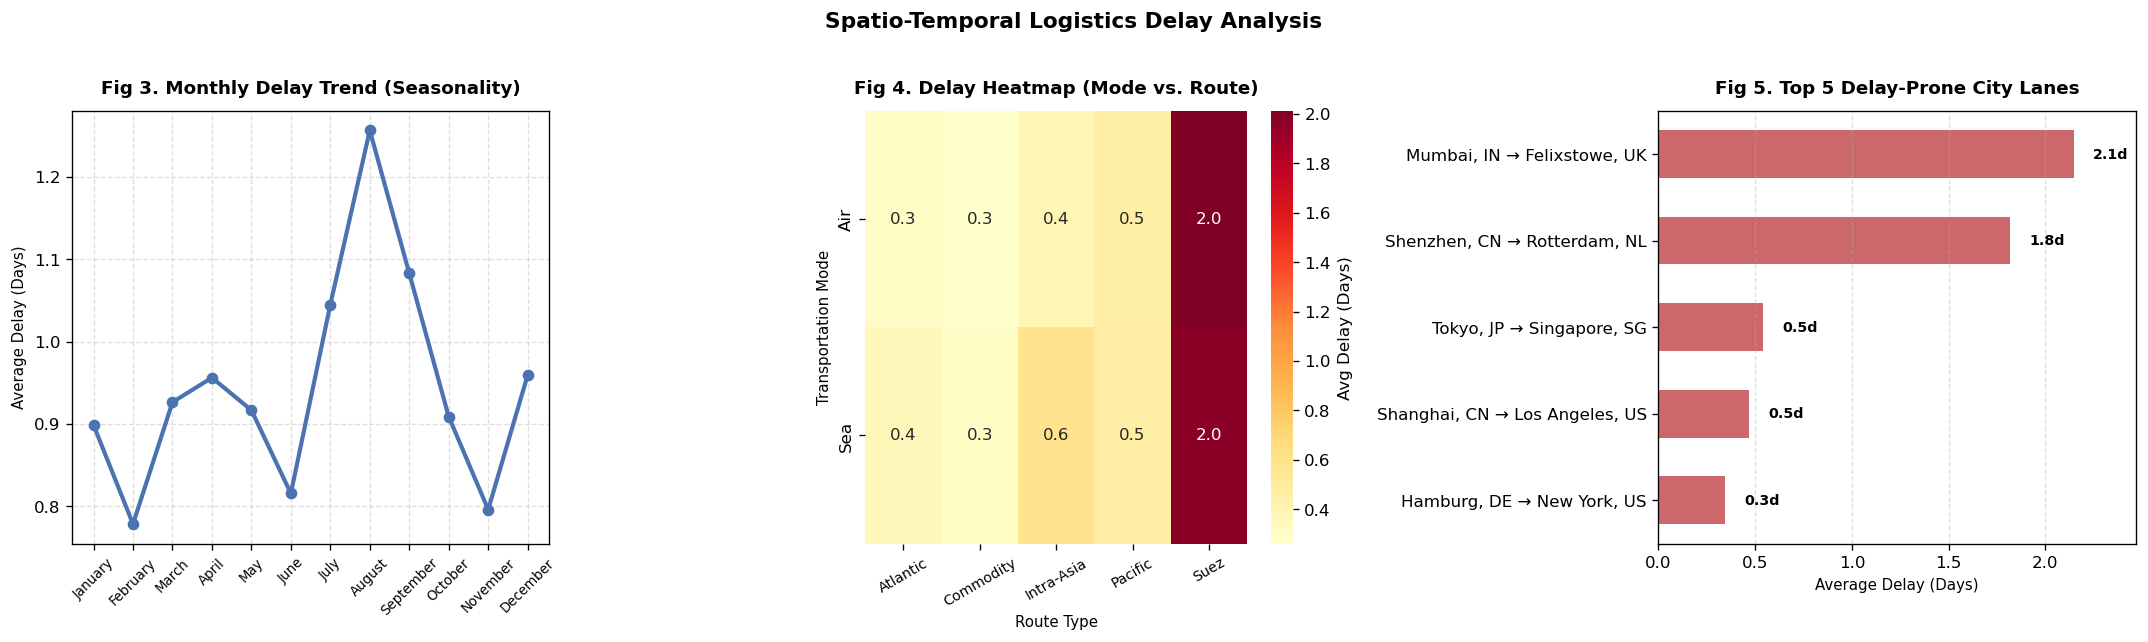

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df['Order_Date'] = pd.to_datetime(df['Order_Date'])
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), dpi=120)
plt.subplots_adjust(wspace=0.35)

# Figure 3: Seasonality / Monthly Delay Trend (by Order_Date)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_delay = df.groupby(df['Order_Date'].dt.month_name())['Delay_Days'].mean().reindex(month_order).dropna()

axes[0].plot(monthly_delay.index, monthly_delay.values, marker='o', color='#4c72b0', linewidth=2.5, markersize=6)
axes[0].set_title('Fig 3. Monthly Delay Trend (Seasonality)', fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel('Average Delay (Days)', fontsize=9)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Figure 4: Delay Heatmap (Transportation Mode vs Route Type)
pivot_mode_route = df.pivot_table(index='Transportation_Mode', columns='Route_Type', values='Delay_Days', aggfunc='mean')
sns.heatmap(pivot_mode_route, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1], cbar_kws={'label': 'Avg Delay (Days)'})
axes[1].set_title('Fig 4. Delay Heatmap (Mode vs. Route)', fontsize=11, fontweight='bold', pad=10)
axes[1].set_xlabel('Route Type', fontsize=9)
axes[1].set_ylabel('Transportation Mode', fontsize=9)
axes[1].tick_params(axis='x', rotation=30, labelsize=8.5)

# Figure 5: Worst City Corridors (Origin to Destination)
df['City_Lane'] = df['Origin_City'] + ' → ' + df['Destination_City']
top_lanes = df.groupby('City_Lane')['Delay_Days'].mean().nlargest(5).iloc[::-1]

bars = axes[2].barh(top_lanes.index, top_lanes.values, color='#c44e52', alpha=0.85, height=0.55)
for bar in bars:
    width = bar.get_width()
    axes[2].text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.1f}d', va='center', fontsize=8.5, fontweight='bold')

axes[2].set_title('Fig 5. Top 5 Delay-Prone City Lanes', fontsize=11, fontweight='bold', pad=10)
axes[2].set_xlabel('Average Delay (Days)', fontsize=9)
axes[2].set_xlim(0, max(top_lanes.values) * 1.15)
axes[2].grid(True, linestyle='--', alpha=0.4, axis='x')

plt.suptitle('Spatio-Temporal Logistics Delay Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Key takeaways:

- Delays spike sharply during summer peaking in August before dropping. (Fig 3)
- The Suez Canal route causes a major 2-day delay across all transportation mode (Air and Sea). (Fig 4)
- Shipping routes connecting Asia to Europe face the worst delays. (Fig 5)

## Spatio-Temporal Disruption Risk Framework

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import prince
except ImportError:
    prince = None

# Load Dataset
df = pd.read_csv(r"C:\Users\leler\Documents\Personal project\Global Supply Chain Disruption & Resilience\archive\global_supply_chain_disruption_v1.csv")

# Extract Temporal and Route Complexity Features
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Order_Month'] = df['Order_Date'].dt.month
df['Quarter'] = df['Order_Date'].dt.quarter

# Target Encode High-Cardinality Cities (Replaces sparse dummy variables with mean historical delay)
city_delay_origin = df.groupby('Origin_City')['Delay_Days'].transform('mean')
city_delay_dest = df.groupby('Destination_City')['Delay_Days'].transform('mean')

df['Origin_Risk_Score'] = city_delay_origin
df['Destination_Risk_Score'] = city_delay_dest

# Factor Analysis of Mixed Data (FAMD)
famd_cols = [
    'Geopolitical_Risk_Index', 'Weather_Severity_Index', 'Inflation_Rate_Pct',
    'Shipping_Cost_USD', 'Order_Weight_Kg', 'Transportation_Mode', 'Route_Type'
]

if prince:
    famd = prince.FAMD(n_components=5, random_state=42)
    famd_results = famd.fit(df[famd_cols])
    print("FAMD Component Coordinates:")
    display(famd.row_coordinates(df[famd_cols]).head())
else:
    print("Prince library not installed. Using Standard One-Hot Encoding fallback.")

Prince library not installed. Using Standard One-Hot Encoding fallback.


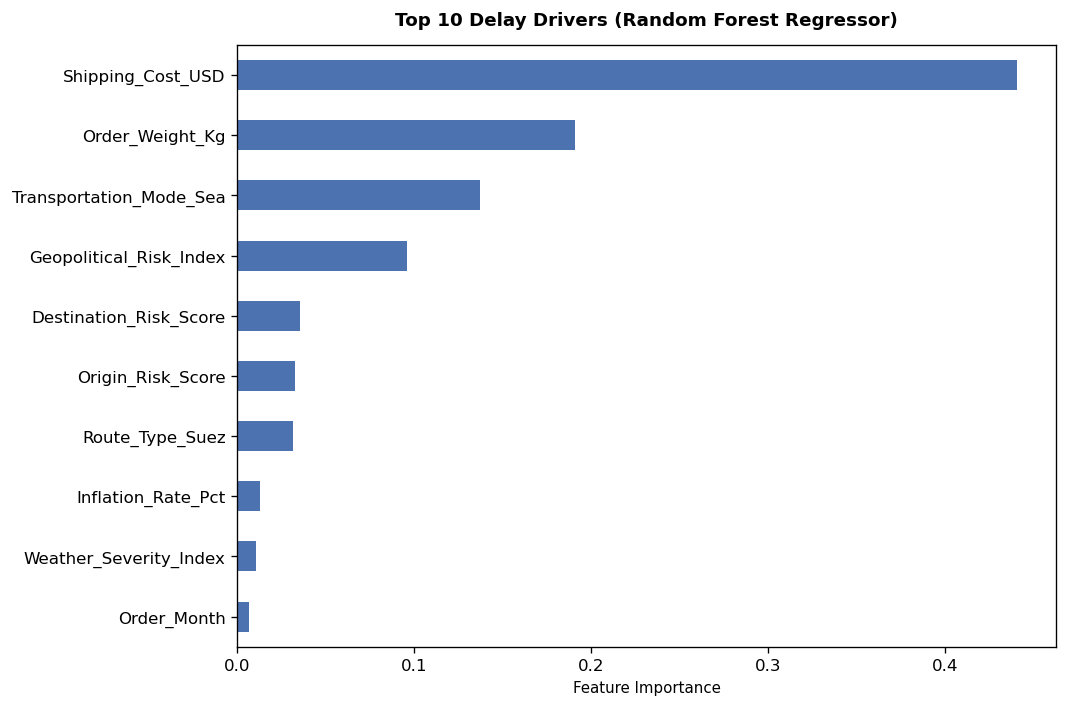

In [26]:
!pip install xgboost shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

X_cols = [
    'Shipping_Cost_USD', 'Order_Weight_Kg', 'Geopolitical_Risk_Index',
    'Weather_Severity_Index', 'Inflation_Rate_Pct', 'Origin_Risk_Score',
    'Destination_Risk_Score', 'Order_Month', 'Quarter'
]

cat_features = ['Transportation_Mode', 'Route_Type', 'Product_Category']
X_encoded = pd.get_dummies(df[X_cols + cat_features], drop_first=True)
y_delay = df['Delay_Days']

# Train Model using Scikit-Learn RandomForest
model_rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
model_rf.fit(X_encoded, y_delay)

# Plot Feature Importance
importances = pd.Series(model_rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6), dpi=120)
importances.tail(10).plot(kind='barh', color='#4c72b0')
plt.title("Top 10 Delay Drivers (Random Forest Regressor)", fontsize=11, fontweight="bold", pad=12)
plt.xlabel("Feature Importance", fontsize=9)
plt.tight_layout()
plt.show()

Top 5 Critical Supply Chain Network Hubs


,City,Centrality_Score
5,"Shanghai, CN",0.011111
0,"Hamburg, DE",0.000000
1,"New York, US",0.000000
2,"Mumbai, IN",0.000000
3,"Felixstowe, UK",0.000000


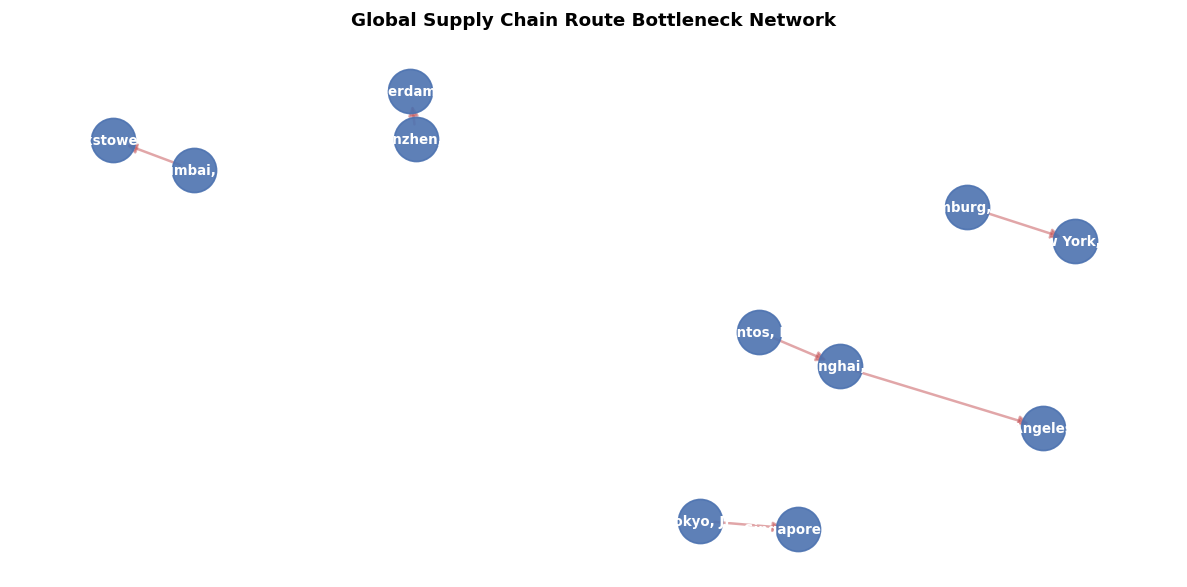

In [27]:
import networkx as nx

G = nx.DiGraph()

route_weights = df.groupby(['Origin_City', 'Destination_City']).agg(
    Avg_Delay=('Delay_Days', 'mean'),
    Volume=('Order_ID', 'count')
).reset_index()

for _, row in route_weights.iterrows():
    G.add_edge(row['Origin_City'], row['Destination_City'], weight=row['Avg_Delay'], volume=row['Volume'])

# Critical network hubs
centrality = nx.betweenness_centrality(G, weight='weight')
top_hubs = pd.DataFrame(list(centrality.items()), columns=['City', 'Centrality_Score']).sort_values(by='Centrality_Score', ascending=False)

print("Top 5 Critical Supply Chain Network Hubs")
display(top_hubs.head(5))

# Plot Network Graph
plt.figure(figsize=(10, 5), dpi=120)
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='#4c72b0', alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.5, edge_color='#c44e52', arrowsize=12)

plt.title("Global Supply Chain Route Bottleneck Network", fontsize=11, fontweight="bold", pad=12)
plt.axis('off')
plt.tight_layout()
plt.show()

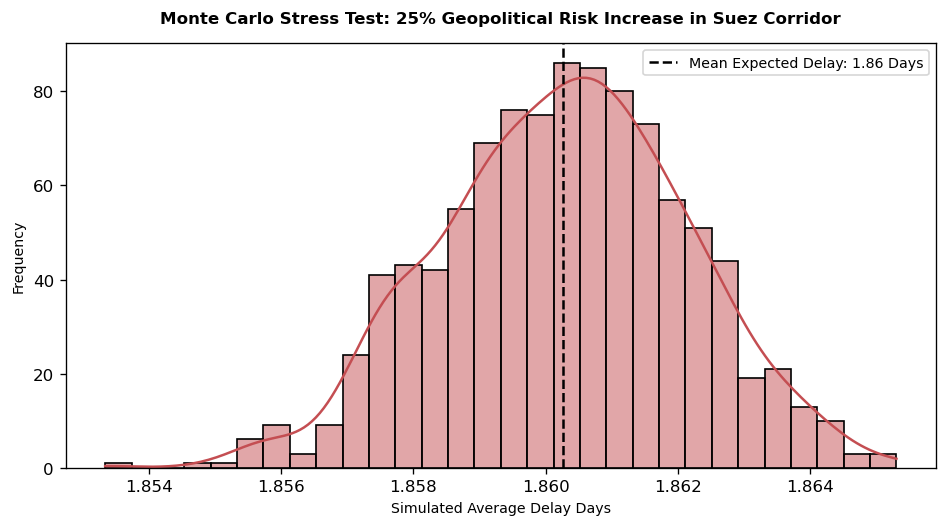

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Monte Carlo Simulation
def run_suez_disruption_simulation(model, data, risk_increase_pct=0.25, num_simulations=1000):
    simulated_delays = []
    # Filter for Suez corridor transactions
    if 'Route_Type_Suez' in data.columns:
        suez_mask = data['Route_Type_Suez'] == 1
    else:
        suez_mask = data['Route_Type'] == 'Suez' 
    suez_data = data[suez_mask].copy()
    for _ in range(num_simulations):
        # Geopolitical risk index with Gaussian noise
        suez_data_stressed = suez_data.copy()
        suez_data_stressed['Geopolitical_Risk_Index'] *= np.random.normal(1 + risk_increase_pct, 0.05, len(suez_data_stressed))
        # Predict delay days using the fitted model
        pred_delays = model.predict(suez_data_stressed[X_encoded.columns])
        simulated_delays.append(np.mean(pred_delays))
    return np.array(simulated_delays)

# Simulation
sim_results = run_suez_disruption_simulation(model_rf, X_encoded, risk_increase_pct=0.25)

# Plot Risk Distribution
plt.figure(figsize=(8, 4.5), dpi=120)
sns.histplot(sim_results, kde=True, color='#c44e52', bins=30)
plt.axvline(np.mean(sim_results), color='black', linestyle='--', label=f'Mean Expected Delay: {np.mean(sim_results):.2f} Days')
plt.title("Monte Carlo Stress Test: 25% Geopolitical Risk Increase in Suez Corridor", fontsize=10, fontweight="bold", pad=12)
plt.xlabel("Simulated Average Delay Days", fontsize=8.5)
plt.ylabel("Frequency", fontsize=8.5)
plt.legend(fontsize=8.5)
plt.tight_layout()
plt.show()